<a href="https://colab.research.google.com/github/srijalgiri/Ai-ML_sem6/blob/main/2413995_Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Install if needed
!pip install tensorflow matplotlib pillow scikit-learn

# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train"

# Get class names
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes:", class_names)

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [9]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [10]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class Distribution:
acai: 15
cupuacu: 15
graviola: 15
guarana: 15
pupunha: 15
tucuma: 15


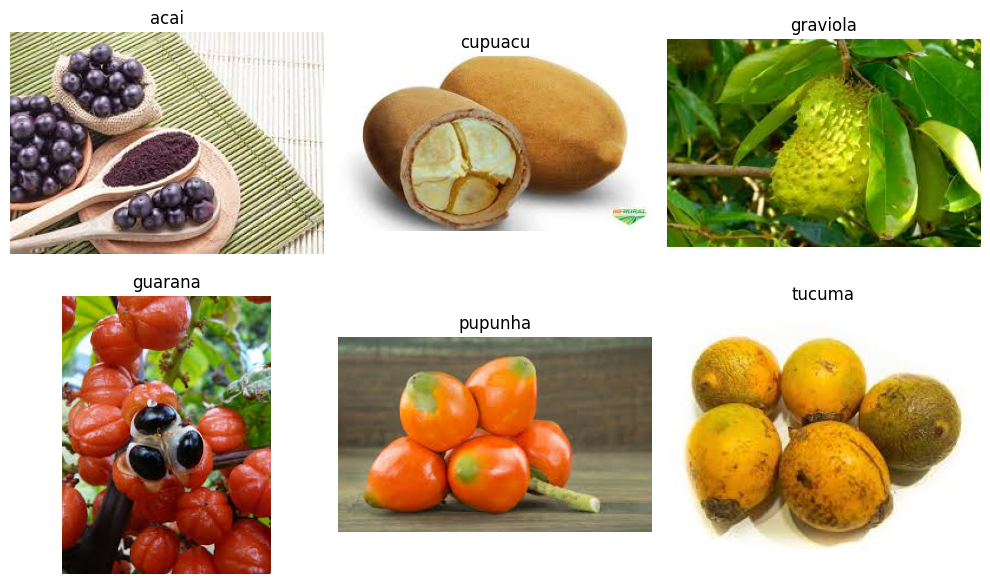

In [11]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

# Plot
cols = 3
rows = (len(selected_images) + 2) // 3

plt.figure(figsize=(10, 6))

for i, img_path in enumerate(selected_images):
    plt.subplot(rows, cols, i+1)
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


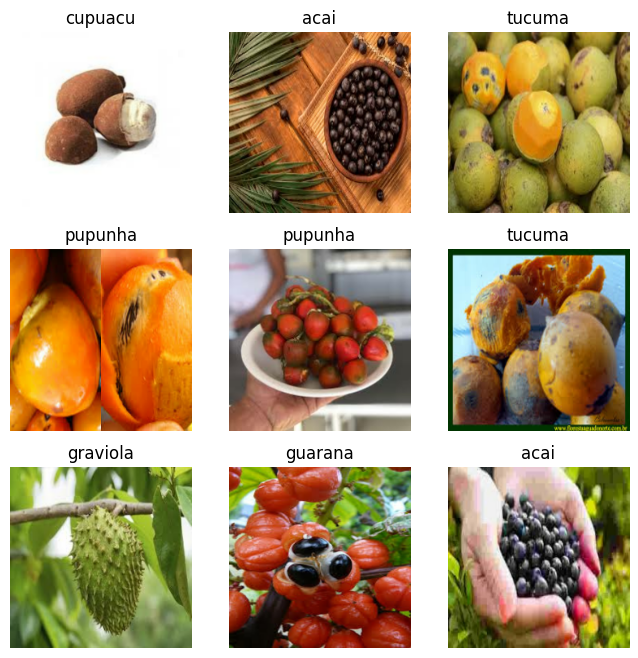

In [13]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [15]:
model = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.2222 - loss: 2.7040 - val_accuracy: 0.1111 - val_loss: 2.0444
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.4444 - loss: 1.6515 - val_accuracy: 0.3333 - val_loss: 1.7589
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.5694 - loss: 0.9628 - val_accuracy: 0.3333 - val_loss: 1.7132
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.7500 - loss: 0.7480 - val_accuracy: 0.2778 - val_loss: 1.8190
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7222 - loss: 0.7373 - val_accuracy: 0.1111 - val_loss: 2.1040
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.7361 - loss: 0.5311 - val_accuracy: 0.1111 - val_loss: 2.3823
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.6806 - loss: 0.6368 - val_accuracy: 0.1111 - val_loss: 2.5275
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.7361 - loss: 0.6860 - val_accuracy: 0.1111 - val_loss: 2.5634
Epoch 9/

In [18]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step - accuracy: 0.1111 - loss: 2.6942
Validation Accuracy: 0.1111111119389534


In [19]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    print("Predicted:", pred_labels[:5])
    print("Actual:   ", labels[:5].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: [1 1 1 1 1]
Actual:    [5 2 0 4 3]


In [20]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
for layer in base_model.layers:
    layer.trainable = False

In [22]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

In [23]:
from tensorflow.keras.models import Model

model_vgg = Model(inputs=base_model.input, outputs=outputs)

In [24]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 16s/step - accuracy: 0.2500 - loss: 5.7167 - val_accuracy: 0.1667 - val_loss: 7.4239
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 17s/step - accuracy: 0.5833 - loss: 2.1667 - val_accuracy: 0.4444 - val_loss: 3.7283
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 21s/step - accuracy: 0.7917 - loss: 0.8576 - val_accuracy: 0.6111 - val_loss: 2.6280
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.9722 - loss: 0.1047 - val_accuracy: 0.5000 - val_loss: 2.6404
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 16s/step - accuracy: 0.9722 - loss: 0.0763 - val_accuracy: 0.5000 - val_loss: 2.5452
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 21s/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 0.5556 - val_loss: 2.2135
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.6111 - val_loss: 2.0435
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 95s 25s/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.6111 - val_loss: 1.9533


In [26]:
loss, acc = model_vgg.evaluate(val_ds)
print("VGG16 Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.6667 - loss: 1.8992
VGG16 Accuracy: 0.6666666865348816


In [27]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.50      0.50      0.50         2
    graviola       1.00      1.00      1.00         3
     guarana       0.80      0.80      0.80         5
     pupunha       0.50      0.50      0.50         4
      tucuma       0.67      0.67      0.67         3

    accuracy                           0.67        18
   macro avg       0.58      0.58      0.58        18
weighted avg       0.67      0.67      0.67        18

